### Training a Teacher Model on MNIST

In this notebook, we will train a neural network (Teacher Model) on the MNIST dataset using PyTorch. This is the first step towards our goal of knowledge distillation. We will later use this trained model to train a smaller Student Model.


#### 1. Import Libraries

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

#### 2. Setting Hyperparameters and Configuration

Here, we define the hyperparameters for our model training, including batch size, learning rate, and number of epochs. We also configure the device to use GPU if available.


In [16]:
# Hyperparameters
batch_size = 64
learning_rate = 0.001
num_epochs = 10

# Device configuration (GPU if available)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Using device: {device}")


Using device: cuda


#### 3. Loading the MNIST Dataset

The MNIST dataset is loaded using PyTorch's `torchvision` package. We normalize the dataset as part of preprocessing.


In [17]:
# MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

print("MNIST dataset loaded successfully.")

MNIST dataset loaded successfully.


#### 4. Defining the Teacher Model , loss function and optimizer

We will define our Teacher Model as a simple Artificial Neural Network (ANN) with three fully connected layers, Cross-entropy Loss and ADAM optimizer



In [18]:
# Define the teacher model (a simple ANN)
class TeacherANN(nn.Module):
    def __init__(self):
        super(TeacherANN, self).__init__()
        self.fc1 = nn.Linear(28*28, 512)  # First fully connected layer
        self.fc2 = nn.Linear(512, 256)    # Second fully connected layer
        self.fc3 = nn.Linear(256, 128)    # Second fully connected layer
        self.fc4 = nn.Linear(128, 10)     # Output layer

    def forward(self, x):
        x = x.view(-1, 28*28)  # Flatten the input image
        x = F.relu(self.fc1(x))  # Apply ReLU activation
        x = F.relu(self.fc2(x))  # Apply ReLU activation
        x = F.relu(self.fc3(x))  # Apply ReLU activation
        x = self.fc4(x)  # Output logits
        return x

# Initialize the teacher model
teacher_model = TeacherANN().to(device)
print("Teacher model (ANN) defined successfully.")


# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(teacher_model.parameters(), lr=learning_rate)

print("Loss function and optimizer initialized.")

# Calculate and print the number of parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model_size = count_parameters(teacher_model)
print(f"Teacher model (ANN) defined successfully. Total parameters: {model_size}")


Teacher model (ANN) defined successfully.
Loss function and optimizer initialized.
Teacher model (ANN) defined successfully. Total parameters: 567434


#### 5. Training the Teacher Model (ANN)

We train the Teacher Model (ANN) on the MNIST dataset. The model will run through several epochs, and we will print the loss at regular intervals.


In [19]:
# Training the teacher model
def train(model, train_loader, criterion, optimizer, num_epochs):
    model.train()
    for epoch in range(num_epochs):
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            
            # Forward pass
            output = model(data)
            loss = criterion(output, target)
            
            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            if batch_idx % 100 == 0:
                print(f'Epoch [{epoch+1}/{num_epochs}], Step [{batch_idx+1}/{len(train_loader)}], Loss: {loss.item():.4f}')

train(teacher_model, train_loader, criterion, optimizer, num_epochs)


Epoch [1/10], Step [1/938], Loss: 2.3047
Epoch [1/10], Step [101/938], Loss: 0.5645
Epoch [1/10], Step [201/938], Loss: 0.4433
Epoch [1/10], Step [301/938], Loss: 0.1831
Epoch [1/10], Step [401/938], Loss: 0.2464
Epoch [1/10], Step [501/938], Loss: 0.2376
Epoch [1/10], Step [601/938], Loss: 0.3761
Epoch [1/10], Step [701/938], Loss: 0.0768
Epoch [1/10], Step [801/938], Loss: 0.2344
Epoch [1/10], Step [901/938], Loss: 0.1088
Epoch [2/10], Step [1/938], Loss: 0.1487
Epoch [2/10], Step [101/938], Loss: 0.0197
Epoch [2/10], Step [201/938], Loss: 0.3365
Epoch [2/10], Step [301/938], Loss: 0.0483
Epoch [2/10], Step [401/938], Loss: 0.1512
Epoch [2/10], Step [501/938], Loss: 0.0457
Epoch [2/10], Step [601/938], Loss: 0.0434
Epoch [2/10], Step [701/938], Loss: 0.0214
Epoch [2/10], Step [801/938], Loss: 0.0358
Epoch [2/10], Step [901/938], Loss: 0.1016
Epoch [3/10], Step [1/938], Loss: 0.0522
Epoch [3/10], Step [101/938], Loss: 0.0562
Epoch [3/10], Step [201/938], Loss: 0.1221
Epoch [3/10], Ste

#### 8. Evaluate the Teacher Model and Saving the Teacher Model (ANN)


After training, we evaluate the model's accuracy on the test set.

Finally, we save the trained Teacher Model (ANN) for future use.

In [20]:
# Evaluate the teacher model
def evaluate(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    accuracy = 100 * correct / total
    print(f'Accuracy of the model on the test images: {accuracy:.2f}%')
    return accuracy

teacher_accuracy = evaluate(teacher_model, test_loader)


# Save the teacher model
torch.save(teacher_model.state_dict(), 'teacher_model_ann.pth')
print("Teacher model (ANN) saved successfully.")


Accuracy of the model on the test images: 97.90%
Teacher model (ANN) saved successfully.


In [21]:
import os

# Print the saved model file size
model_file_size = os.path.getsize('teacher_model_ann.pth') / (1024 * 1024)  # Size in MB
print(f"Teacher model (ANN) saved successfully. File size: {model_file_size:.2f} MB")

Teacher model (ANN) saved successfully. File size: 2.17 MB


#### Student Model without Distillation

In [22]:
# Define the student model (a smaller ANN)
class StudentANN(nn.Module):
    def __init__(self):
        super(StudentANN, self).__init__()
        self.fc1 = nn.Linear(28*28, 16)  # Smaller first fully connected layer
        self.fc2 = nn.Linear(16, 8)    # Smaller second fully connected layer
        self.fc3 = nn.Linear(8, 10)     # Output layer

    def forward(self, x):
        x = x.view(-1, 28*28)  # Flatten the input image
        x = F.relu(self.fc1(x))  # Apply ReLU activation
        x = F.relu(self.fc2(x))  # Apply ReLU activation
        x = self.fc3(x)  # Output logits
        return x

# Initialize the student model
student_model = StudentANN().to(device)

# Calculate and print the number of parameters
student_model_size = count_parameters(student_model)
print(f"Student model (ANN) defined successfully. Total parameters: {student_model_size}")

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(student_model.parameters(), lr=learning_rate)

print("Loss function and optimizer for student model initialized.")

# Training the student model
def train_student(model, train_loader, criterion, optimizer, num_epochs):
    model.train()
    for epoch in range(num_epochs):
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            
            # Forward pass
            output = model(data)
            loss = criterion(output, target)
            
            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            if batch_idx % 100 == 0:
                print(f'Epoch [{epoch+1}/{num_epochs}], Step [{batch_idx+1}/{len(train_loader)}], Loss: {loss.item():.4f}')

train_student(student_model, train_loader, criterion, optimizer, num_epochs)

# Evaluate the student model
student_accuracy = evaluate(student_model, test_loader)

# Save the student model
torch.save(student_model.state_dict(), 'student_model_ann.pth')

# Print the saved model file size
student_model_file_size = os.path.getsize('student_model_ann.pth') / (1024 * 1024)  # Size in MB
print(f"Student model (ANN) saved successfully. File size: {student_model_file_size:.2f} MB")

Student model (ANN) defined successfully. Total parameters: 12786
Loss function and optimizer for student model initialized.
Epoch [1/10], Step [1/938], Loss: 2.3704
Epoch [1/10], Step [101/938], Loss: 1.2636
Epoch [1/10], Step [201/938], Loss: 0.4521
Epoch [1/10], Step [301/938], Loss: 0.3407
Epoch [1/10], Step [401/938], Loss: 0.3926
Epoch [1/10], Step [501/938], Loss: 0.3366
Epoch [1/10], Step [601/938], Loss: 0.3398
Epoch [1/10], Step [701/938], Loss: 0.4039
Epoch [1/10], Step [801/938], Loss: 0.2152
Epoch [1/10], Step [901/938], Loss: 0.2545
Epoch [2/10], Step [1/938], Loss: 0.2244
Epoch [2/10], Step [101/938], Loss: 0.3987
Epoch [2/10], Step [201/938], Loss: 0.2930
Epoch [2/10], Step [301/938], Loss: 0.2651
Epoch [2/10], Step [401/938], Loss: 0.3404
Epoch [2/10], Step [501/938], Loss: 0.3628
Epoch [2/10], Step [601/938], Loss: 0.1978
Epoch [2/10], Step [701/938], Loss: 0.2483
Epoch [2/10], Step [801/938], Loss: 0.3077
Epoch [2/10], Step [901/938], Loss: 0.2707
Epoch [3/10], Step 

#### 9. Training student model with distillation 

We define the distillation loss as a combination of the cross-entropy loss with the true labels and the cross-entropy loss between the student model's outputs and the teacher model's softened outputs (soft targets).


In [27]:
def distillation_loss(y_student, y_teacher, y_true, temperature, alpha):
    """
    Compute the distillation loss.
    
    Parameters:
    y_student: Logits from the student model
    y_teacher: Logits from the teacher model
    y_true: Ground truth labels
    temperature: Temperature for soft targets
    alpha: Weight for the distillation loss
    
    Returns:
    Loss value
    """
    # Cross-entropy loss with true labels
    loss_ce = F.cross_entropy(y_student, y_true)
    
    # Soft targets from the teacher model
    y_teacher_soft = F.softmax(y_teacher / temperature, dim=1)
    y_student_soft = F.log_softmax(y_student / temperature, dim=1)
    
    # Cross-entropy loss with soft targets
    loss_soft = F.kl_div(y_student_soft, y_teacher_soft, reduction='batchmean') * (temperature ** 2)
    
    # Combine the two losses
    loss = alpha * loss_soft + (1.0 - alpha) * loss_ce
    return loss


def train_with_distillation(student_model, teacher_model, train_loader, criterion, optimizer, num_epochs, temperature=2.0, alpha=0.7):
    teacher_model.eval()  # Ensure the teacher model is in evaluation mode
    student_model.train()
    
    for epoch in range(num_epochs):
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            
            # Forward pass through the teacher and student models
            with torch.no_grad():
                teacher_outputs = teacher_model(data)
            student_outputs = student_model(data)
            
            # Compute the distillation loss
            loss = criterion(student_outputs, teacher_outputs, target, temperature, alpha)
            
            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            if batch_idx % 100 == 0:
                print(f'Epoch [{epoch+1}/{num_epochs}], Step [{batch_idx+1}/{len(train_loader)}], Loss: {loss.item():.4f}')

train_with_distillation(student_model, teacher_model, train_loader, distillation_loss, optimizer, num_epochs)


Epoch [1/10], Step [1/938], Loss: 0.3568
Epoch [1/10], Step [101/938], Loss: 0.5112
Epoch [1/10], Step [201/938], Loss: 0.3039
Epoch [1/10], Step [301/938], Loss: 0.2789
Epoch [1/10], Step [401/938], Loss: 0.2451
Epoch [1/10], Step [501/938], Loss: 0.3552
Epoch [1/10], Step [601/938], Loss: 0.3631
Epoch [1/10], Step [701/938], Loss: 0.3696
Epoch [1/10], Step [801/938], Loss: 0.3584
Epoch [1/10], Step [901/938], Loss: 0.4568
Epoch [2/10], Step [1/938], Loss: 0.4354
Epoch [2/10], Step [101/938], Loss: 0.2683
Epoch [2/10], Step [201/938], Loss: 0.3131
Epoch [2/10], Step [301/938], Loss: 0.5050
Epoch [2/10], Step [401/938], Loss: 0.3429
Epoch [2/10], Step [501/938], Loss: 0.3236
Epoch [2/10], Step [601/938], Loss: 0.1376
Epoch [2/10], Step [701/938], Loss: 0.3124
Epoch [2/10], Step [801/938], Loss: 0.6775
Epoch [2/10], Step [901/938], Loss: 0.5634
Epoch [3/10], Step [1/938], Loss: 0.2116
Epoch [3/10], Step [101/938], Loss: 0.5176
Epoch [3/10], Step [201/938], Loss: 0.1834
Epoch [3/10], Ste

In [28]:
student_distilled_accuracy = evaluate(student_model, test_loader)

# Save the distilled student model
torch.save(student_model.state_dict(), 'student_model_distilled.pth')

# Print the saved model file size
student_distilled_model_file_size = os.path.getsize('student_model_distilled.pth') / (1024 * 1024)  # Size in MB
print(f"Distilled student model (ANN) saved successfully. File size: {student_distilled_model_file_size:.2f} MB")


Accuracy of the model on the test images: 95.12%
Distilled student model (ANN) saved successfully. File size: 0.05 MB


In [29]:
print(f"Teacher Model Accuracy: {teacher_accuracy:.2f}%")
print(f"Standard Student Model Accuracy: {student_accuracy:.2f}%")
print(f"Distilled Student Model Accuracy: {student_distilled_accuracy:.2f}%")
print(f"Teacher Model Size: {model_file_size:.2f} MB")
print(f"Standard Student Model Size: {student_model_file_size:.2f} MB")
print(f"Distilled Student Model Size: {student_distilled_model_file_size:.2f} MB")


Teacher Model Accuracy: 97.90%
Standard Student Model Accuracy: 94.50%
Distilled Student Model Accuracy: 95.12%
Teacher Model Size: 2.17 MB
Standard Student Model Size: 0.05 MB
Distilled Student Model Size: 0.05 MB



Training with temperature: 1.0
Epoch [1/10], Step [1/938], Loss: 2.2911
Epoch [1/10], Step [101/938], Loss: 0.9444
Epoch [1/10], Step [201/938], Loss: 0.5033
Epoch [1/10], Step [301/938], Loss: 0.4000
Epoch [1/10], Step [401/938], Loss: 0.2776
Epoch [1/10], Step [501/938], Loss: 0.3461
Epoch [1/10], Step [601/938], Loss: 0.2772
Epoch [1/10], Step [701/938], Loss: 0.4493
Epoch [1/10], Step [801/938], Loss: 0.2326
Epoch [1/10], Step [901/938], Loss: 0.1667
Epoch [2/10], Step [1/938], Loss: 0.3725
Epoch [2/10], Step [101/938], Loss: 0.2313
Epoch [2/10], Step [201/938], Loss: 0.3959
Epoch [2/10], Step [301/938], Loss: 0.2891
Epoch [2/10], Step [401/938], Loss: 0.1479
Epoch [2/10], Step [501/938], Loss: 0.3706
Epoch [2/10], Step [601/938], Loss: 0.3336
Epoch [2/10], Step [701/938], Loss: 0.3492
Epoch [2/10], Step [801/938], Loss: 0.3097
Epoch [2/10], Step [901/938], Loss: 0.1458
Epoch [3/10], Step [1/938], Loss: 0.4405
Epoch [3/10], Step [101/938], Loss: 0.1129
Epoch [3/10], Step [201/938]

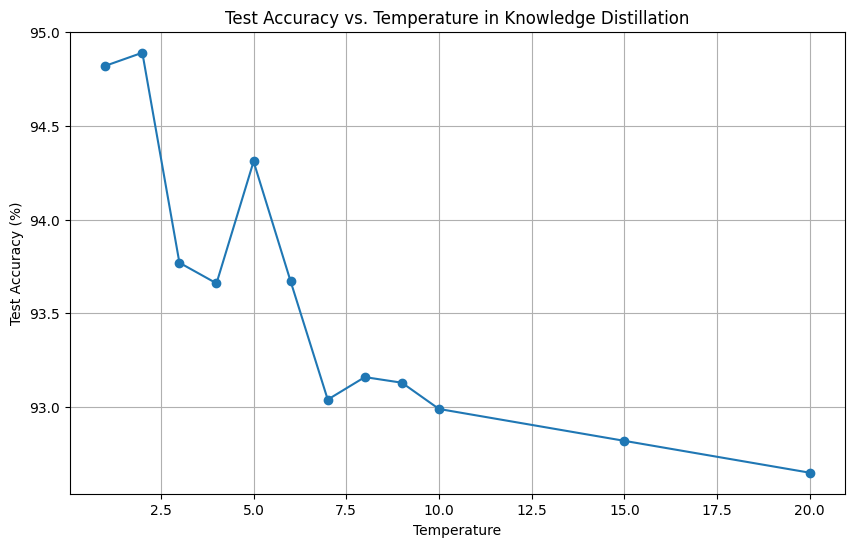

In [31]:
def train_with_distillation_multiple_temperatures(student_model, teacher_model, train_loader, test_loader, criterion, optimizer, num_epochs, temperatures, alpha=0.7):
    accuracy_results = {}

    for temperature in temperatures:
        print(f"\nTraining with temperature: {temperature}")
        
        # Reinitialize the student model for each temperature to avoid interference
        student_model.apply(lambda m: m.reset_parameters() if hasattr(m, 'reset_parameters') else None)
        
        for epoch in range(num_epochs):
            student_model.train()
            for batch_idx, (data, target) in enumerate(train_loader):
                data, target = data.to(device), target.to(device)
                
                # Forward pass through the teacher and student models
                with torch.no_grad():
                    teacher_outputs = teacher_model(data)
                student_outputs = student_model(data)
                
                # Compute the distillation loss
                loss = criterion(student_outputs, teacher_outputs, target, temperature, alpha)
                
                # Backward pass and optimization
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                
                if batch_idx % 100 == 0:
                    print(f'Epoch [{epoch+1}/{num_epochs}], Step [{batch_idx+1}/{len(train_loader)}], Loss: {loss.item():.4f}')

        # Evaluate the model on the test set
        student_accuracy = evaluate(student_model, test_loader)
        accuracy_results[temperature] = student_accuracy
        print(f"Test accuracy with temperature {temperature}: {student_accuracy:.2f}%")
    
    return accuracy_results


import matplotlib.pyplot as plt

# List of different temperatures to try
temperatures = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 15.0, 20.0]

# Optimizer needs to be reinitialized for each temperature run
optimizer = optim.Adam(student_model.parameters(), lr=learning_rate)

# Run the training with different temperatures
accuracy_results = train_with_distillation_multiple_temperatures(student_model, teacher_model, train_loader, test_loader, distillation_loss, optimizer, num_epochs, temperatures)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(list(accuracy_results.keys()), list(accuracy_results.values()), marker='o')
plt.title("Test Accuracy vs. Temperature in Knowledge Distillation")
plt.xlabel("Temperature")
plt.ylabel("Test Accuracy (%)")
plt.grid(True)
plt.show()
